## Bibliothèques

In [1]:
1

1

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))
import geopandas as gpd
import sys
sys.executable
import numpy as np

#### librairie "morta_nuts2" construite

In [3]:
from morta_nuts2.data.eurostat import Eurostat_data, EurostatConfig
from morta_nuts2.data.mortality_table import MortalityCalculator, MortalityConfig
from morta_nuts2.model.Bsplines.Bsplines import make_bspline_basis
from morta_nuts2.model.parameters_init.param_init import*
from morta_nuts2.model.projection.project import project_LC_prospective_SVD,high_age_extrapolation,project_LeeLi_prospective,life_expectancy,high_age_extrapolation_snd
from morta_nuts2.graph.plot import*

In [4]:
#from morta_nuts2.data.raw_data import*
#from morta_nuts2.data.raw import*
#from morta_nuts2.data.processed import*
from morta_nuts2.model.LC_p.lc_p import LCp_fit, LC_fit, build_input_from_dataframe,LCp_multiregion_fit
#from morta_nuts2.model.LC.lc import
from morta_nuts2.model.LL_p.ll_p import LiLee_p_fit, LandL_fit



### Test fonctions imports de data eurostat

In [5]:

# Option 1: Le chemin par défaut est déjà bon : sans path ils stock dans la data dans le lieu ou se trouve votre script

# Option 2: Changer le chemin par défaut pour toute l'application
#EurostatConfig.set_default_shapefile("D:/mes_donnees/NUTS_2024.shp") # implémenter par defaut mais possible de le changer
EurostatConfig.set_default_data_path("C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data")

data_brute = Eurostat_data()

#Chargement des données - ultra simple
mortality_fr = data_brute.load("mortality", "FR")
deaths_fr = data_brute.load("deaths", "FR")
population_fr = data_brute.load("population", "FR")


#Tout charger d'un coup en dictionnaire
#data_fr = data_brute.load_all("FR")




📂 Chargement du shapefile NUTS... NUTS_RG_01M_2024_3035.shp
✅ Shapefile chargé (1798 entités)
💾 [Eurostat] Cache → FR_mxt_raw.csv
💾 [Eurostat] Cache → FR_Dxt_raw.csv
💾 [Eurostat] Cache → FR_Lxt_raw.csv


In [6]:
data_fr = data_brute.load_all("FR")

💾 [Eurostat] Cache → FR_mxt_raw.csv
💾 [Eurostat] Cache → FR_Dxt_raw.csv
💾 [Eurostat] Cache → FR_Lxt_raw.csv


In [7]:
#data_fr["deaths"]

In [8]:
#population_fr

In [9]:
#mortality_fr

In [10]:
#df_agg = Dxt_raw.groupby(["geo", "sex", "time"])["values"].sum().reset_index()

### Test fonction renvoyant le nombre de décès, l'exposition et les taux de mortalité brutes par région

In [11]:
morta = MortalityCalculator()
table = morta.calculate_mortality(mortality_fr,population_fr,deaths_fr,gender="T")

2026-03-02 17:39:24,425 - MortalityCalculator - INFO - Chargement du shapefile: C:/Users/Idrissa Belem/Documents/GitHub/test_projet/NUTS_files/NUTS_RG_01M_2024_3035.shp


2026-03-02 17:39:24,717 - MortalityCalculator - INFO - 1793 régions chargées
2026-03-02 17:39:24,741 - MortalityCalculator - INFO - MortalityCalculator initialisé avec 1793 régions
2026-03-02 17:39:24,744 - MortalityCalculator - INFO - Validation des données d'entrée...
2026-03-02 17:39:29,033 - MortalityCalculator - INFO - Validation réussie
2026-03-02 17:39:29,034 - root - INFO - validate_input_data exécuté en 4.29 secondes
2026-03-02 17:39:29,205 - MortalityCalculator - INFO - Âges harmonisés: 96 âges communs
2026-03-02 17:39:29,206 - MortalityCalculator - INFO - Construction des pivots...
2026-03-02 17:39:29,470 - MortalityCalculator - INFO - Traitement de 22 régions avec 20 threads
2026-03-02 17:39:29,512 - MortalityCalculator - INFO - Progression: 10/22 régions traitées
2026-03-02 17:39:29,516 - MortalityCalculator - INFO - Progression: 20/22 régions traitées
2026-03-02 17:39:29,517 - MortalityCalculator - INFO - Progression: 22/22 régions traitées
2026-03-02 17:39:29,520 - root 

In [12]:
#table

In [13]:
#données d'entrée modèles
dictio = build_input_from_dataframe(table)
#dictio

In [14]:
#test_table_by_age = mortality_by_region_by_age(mortality_fr,population_fr,deaths_fr,regions)
#test_table_by_age

#### Paramètres

In [15]:
Muxtg,Dxtg, Extg, xv, tv, regions = build_input_from_dataframe(table)

print("Shape Dxtg :", Dxtg.shape)
print("Shape Extg :", Extg.shape)
print("Shape Muxtg :", Muxtg.shape)
print("Ages :", len(xv))
print("Years :", len(tv))
print("Regions :", len(regions))
nb_regions = len(regions)
nb_years = len(tv)
degree = 3 
n_knots = 10

Dxt = np.sum(Dxtg, axis=2)
Ext = np.sum(Extg, axis=2)


Shape Dxtg : (83, 35, 22)
Shape Extg : (83, 35, 22)
Shape Muxtg : (83, 35, 22)
Ages : 83
Years : 35
Regions : 22


#### modèle Lee carter 

###### modèle Lee carter non paramétrique

In [16]:
nb_iter_LC = 300
#LC initial values
ax_init   = -0.001*np.zeros_like(xv)
bx_init   = 0.001*np.ones_like(xv)
kappa_init= np.ones(len(tv))
# nb parameters
#nb_params_LC = len(ax_init)*2 + len(common_years)
#LC fit
result_lc = LC_fit(ax_init,bx_init,kappa_init,Extg,Dxtg,xv,tv,nb_iter_LC)

###### modèle Lee carter paramétrique

In [17]:
_, _, n_basis = make_bspline_basis(
    xv, degree, n_knots)

In [18]:
ax_coef_init, bx_coef_init, kappa_init = lcp_parametrique_init_national(
    Dxtg, Extg, xv, tv, n_basis=n_basis, degree=2, n_knots=10
)

results = LCp_fit(
    ax_coef_init  = ax_coef_init,
    bx_coef_init  = bx_coef_init,
    kappa_init    = kappa_init,
    Extg=Extg, Dxtg=Dxtg,
    xv=xv, tv=tv,
    degree=2, n_knots=10,
    lam=1.0,
    verbose=True
)

It    0 | lnL = -369857.5811 | Δ = +inf | η = 0.21000
It   10 | lnL = -306510.7516 | Δ = +324.674020 | η = 0.34207
It   20 | lnL = -304066.7835 | Δ = +235.835295 | η = 0.55719
It   30 | lnL = -301887.7660 | Δ = +193.943505 | η = 0.90761
It   40 | lnL = -303709.2927 | Δ = -3078.269259 | η = 1.47840
It   50 | lnL = -300194.5556 | Δ = +18.193091 | η = 0.26003
It   60 | lnL = -300056.6742 | Δ = +14.127514 | η = 0.42356
It   70 | lnL = -299908.3869 | Δ = +14.983683 | η = 0.68994
It   80 | lnL = -299769.0997 | Δ = +12.550756 | η = 1.12384
It   90 | lnL = -299708.3593 | Δ = +1126.170655 | η = 0.19767
It  100 | lnL = -299674.7321 | Δ = +1.380260 | η = 0.32198
It  110 | lnL = -299658.7553 | Δ = +1.764899 | η = 0.52448
It  120 | lnL = -299639.6585 | Δ = +1.990994 | η = 0.85432
It  130 | lnL = -299619.9162 | Δ = +1.906214 | η = 1.39159
It  140 | lnL = -299611.9629 | Δ = +0.240872 | η = 0.24476
It  150 | lnL = -299608.9862 | Δ = +0.347623 | η = 0.39869
It  160 | lnL = -299604.8439 | Δ = +0.469316 

###### modèle Lee carter paramétrique multi regions

In [19]:

# ax_coef_init, bx_coef_init, kappa_init = lcp_bspline_init(
#     Dxtg, Extg, xv, degree, n_knots)

In [20]:
degree = 3 
n_knots = 10

#Construction base spline pour connaître n_basis
B, knots, n_basis = make_bspline_basis(xv, degree, n_knots)

ax_coef_init = np.zeros(n_basis)
bx_coef_init = np.ones((len(regions), n_basis))
kappa_init =  np.ones(len(tv))

In [21]:
result_lcp = LCp_multiregion_fit(
    ax_coef_init=ax_coef_init,
    bx_coef_init=bx_coef_init,
    kappa_init=kappa_init,
    Extg=Extg,
    Dxtg=Dxtg,
    xv=xv,
    tv=tv,
    degree=degree,
    n_knots=n_knots,
    lam=2,
    diff_order=2,
    nb_iter=5000,
    eta0=0.2,
    verbose=True
)

It    0 | lnL = -5607685582.1471 | Δ = +inf | η = 0.21000
It   10 | lnL = -326110.8238 | Δ = +48736.279783 | η = 0.34207
It   20 | lnL = -243017.5407 | Δ = +644.035285 | η = 0.55719
It   30 | lnL = -241409.5617 | Δ = +36.608644 | η = 0.20581
It   40 | lnL = -241108.0742 | Δ = +28.696994 | η = 0.33524
It   50 | lnL = -240766.7255 | Δ = +40.555312 | η = 0.54607
It   60 | lnL = -240246.4445 | Δ = +62.841954 | η = 0.88949
It   70 | lnL = -239448.8862 | Δ = +93.692692 | η = 1.44888
It   80 | lnL = -239021.7149 | Δ = +60.291002 | η = 0.25484
It   90 | lnL = -238784.6006 | Δ = +25.363389 | η = 0.41511
It  100 | lnL = -238456.9521 | Δ = +39.790216 | η = 0.67617
It  110 | lnL = -238172.4695 | Δ = +6.922712 | η = 0.11893
It  120 | lnL = -238083.1872 | Δ = +10.966506 | η = 0.19372
It  130 | lnL = -237939.4716 | Δ = +17.613681 | η = 0.31555
It  140 | lnL = -237709.7732 | Δ = +28.038663 | η = 0.51400
It  150 | lnL = -237347.0399 | Δ = +43.986038 | η = 0.83726
It  160 | lnL = -236785.4226 | Δ = +67.

In [22]:
# result_lcp = LCp_fit(
#     ax_coef_init=ax_init,
#     bx_coef_init=bx_init,
#     kappa_init=kappa_init,
#     Extg=Dxtg,
#     Dxtg=Dxtg,
#     xv=xv,
#     tv=tv,
#     degree=degree,
#     n_knots=n_knots,
#     lam=2,
#     diff_order=2,
#     nb_iter=5000,
#     eta0=0.2,
#     verbose=True
# )


#### Modèle Lee and Li

###### modèle Lee and Li non paramétrique

In [23]:
#------------------------------------------------------------------------------
bx_gr_init    =   0.0000010*np.ones((len(xv),len(regions)))
kappa_gr_init =   0.0000010*np.ones((len(tv),len(regions)))
#number of parameter
h = 0.0          # smoothness
z = 3            # order of difference for smoothness
nb_iterLL = 800
result_ll= LandL_fit(ax_init, 
            bx_init , bx_gr_init ,kappa_init, kappa_gr_init,Extg, Dxtg,Muxtg, 
            xv, tv, nb_iterLL,h,z, verbose=False)

C:\Users\Idrissa Belem\Documents\GitHub\morta_nuts2\src\morta_nuts2\model\LL_p\ll_p.py:708: RuntimeWarning: invalid value encountered in divide
  dlnL_dpar = (np.sum(dlnL_baseline*bxM,axis=(0,2))/(


In [24]:
result_ll["fit_statistics"]

,N,m,degree,dofs,lnL,AIC,BIC
0,63910,NA,NA,2797,NaN,NaN,NaN


###### modèle Lee and Li avec Bsplines paramétrique

In [25]:
(
    alpha_coef_init,
    beta_coef_init,
    beta_g_coef_init,
    kappa_init,
    kappa_g_init
) = lileep_bspline_init(
        Dxtg,
        Extg,
        xv,
        degree,
        n_knots
)


In [26]:
resultat_llp = LiLee_p_fit(
    alpha_coef_init,
    beta_coef_init,
    beta_g_coef_init,
    kappa_init,
    kappa_g_init,
    Extg,
    Dxtg,
    xv,
    tv,
    degree=degree,
    n_knots=n_knots,
    lam=2,
    diff_order=2,
    nb_iter=5000,
    tol=1e-6,
    verbose=True
)


CALIBRATION MODÈLE LI-LEE PARAMÉTRIQUE
Paramètres : degree=3, n_knots=10, lam=2
Données : 83 âges × 35 années × 22 régions
Nombre de fonctions de base : 12
It    0 | lnL = -42,500,996.19 | Δ = -42500996.187007 | η = 0.15000
It   10 | lnL = -693,739.71 | Δ = +137867.051958 | η = 0.11635
It   20 | lnL = -268,222.52 | Δ = +10387.414832 | η = 0.18952
It   30 | lnL = -233,489.97 | Δ = +1508.210881 | η = 0.30871
It   40 | lnL = -225,410.18 | Δ = +470.288071 | η = 0.50286
It   50 | lnL = -240,148.63 | Δ = +3159.955389 | η = 0.18574
It   60 | lnL = -225,602.47 | Δ = -444.665892 | η = 0.00080
It   70 | lnL = -228,315.16 | Δ = -142.580604 | η = 0.00000
It   80 | lnL = -229,005.91 | Δ = -31.841700 | η = 0.00000
It   90 | lnL = -229,155.83 | Δ = -6.764547 | η = 0.00000
It  100 | lnL = -229,187.50 | Δ = -1.422897 | η = 0.00000
It  110 | lnL = -229,194.15 | Δ = -0.298685 | η = 0.00000
It  120 | lnL = -229,195.55 | Δ = -0.062671 | η = 0.00000
It  130 | lnL = -229,195.84 | Δ = -0.013149 | η = 0.00000


In [27]:
#resultat_llp["fit_statistics"]

##### MAE

In [28]:
def compute_mae(mu_obs, mu_model, weights=None):
    """
    Compute MAE and WMAE between observed and modelled mortality rates.

    Parameters
    ----------
    mu_obs   : (nb_ages, horizon, nb_regions)
    mu_model : (nb_ages, horizon, nb_regions) or (nb_ages, horizon) for national model
    weights  : (nb_ages, horizon, nb_regions)  optional, e.g. exposures Extg

    Returns
    -------
    dict with MAE and WMAE (if weights provided) at different aggregation levels
    """
    # If national model (nb_ages, horizon) → broadcast to (nb_ages, horizon, nb_regions)
    if mu_model.ndim == 2:
        mu_model = np.broadcast_to(mu_model[:, :, None], mu_obs.shape)

    abs_err = np.abs(mu_model - mu_obs)

    result = {
        "by_region": np.mean(abs_err, axis=(0, 1)),   # (nb_regions,)
        "by_age":    np.mean(abs_err, axis=(1, 2)),   # (nb_ages,)
        "by_year":   np.mean(abs_err, axis=(0, 2)),   # (horizon,)
        "global":    np.sum(abs_err) / abs_err.size,  # scalar
    }

    if weights is not None:
        result.update({
            "wmae_by_region": np.sum(abs_err * weights, axis=(0, 1)) / np.sum(weights, axis=(0, 1)),
            "wmae_by_age":    np.sum(abs_err * weights, axis=(1, 2)) / np.sum(weights, axis=(1, 2)),
            "wmae_by_year":   np.sum(abs_err * weights, axis=(0, 2)) / np.sum(weights, axis=(0, 2)),
            "wmae_global":    np.sum(abs_err * weights) / np.sum(weights),
        })

    return result

In [29]:
mae_lc = compute_mae(Muxtg, result_lcp['fitted_values']['mu'], weights=Extg)
mae_ll = compute_mae(Muxtg, resultat_llp['fitted_values']['mu'], weights=Extg)

print(f"MAE  global — LC : {mae_lc['global']:.6f} | LL : {mae_ll['global']:.6f}")
print(f"WMAE global — LC : {mae_lc['wmae_global']:.6f} | LL : {mae_ll['wmae_global']:.6f}")

MAE  global — LC : 0.000477 | LL : 0.000485
WMAE global — LC : 0.000311 | LL : 0.000324


In [30]:
def mae(mu_obs, mu_model):
    """
    Compute MAE between observed and modelled mortality rates.

    Parameters
    ----------
    mu_obs   : (nb_ages, horizon, nb_regions)
    mu_model : (nb_ages, horizon, nb_regions)

    Returns
    -------
    mae : (nb_ages, horizon, nb_regions)
    """
    return np.abs(mu_obs - mu_model)

In [31]:
error = mae(Muxtg,resultat_llp['fitted_values']['mu'])

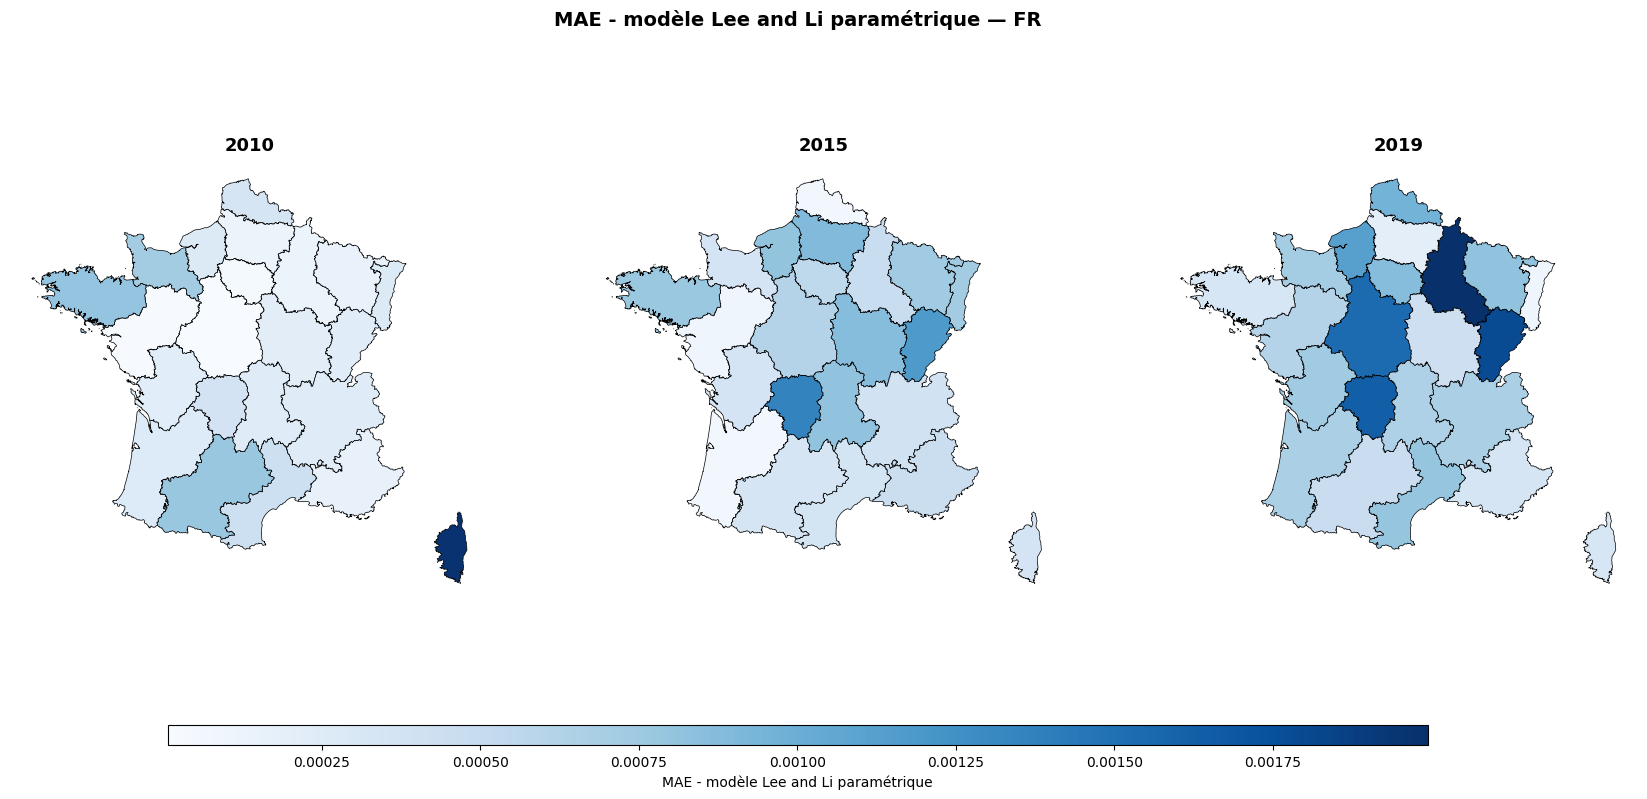

In [32]:
tv_future = np.arange(1990, 2024) #années
plot_map_compare_years(
    regions=regions, data=error,
    tv_future=tv_future, country_code="FR",
    indicator_name="MAE - modèle Lee and Li paramétrique",
    years=[2010,2015, 2019], age=0, cmap="Blues"
)

##### Graphiques

In [37]:
mu_obs = Dxtg / Extg
curves = {
    "Observed": mu_obs,
    "LCp": result_lcp["fitted_values"]['mu'],
    "LL": result_ll["fitted_values"]["mu"],
    "LL_p": resultat_llp["fitted_values"]["mu"]}

In [38]:
# alpha_x = result_lcp["curves"]["alpha_x"]
# beta_x  = result_lcp["curves"]["beta_x"]
mu_fit  = results['fitted_values']['mu']  # (age, year)

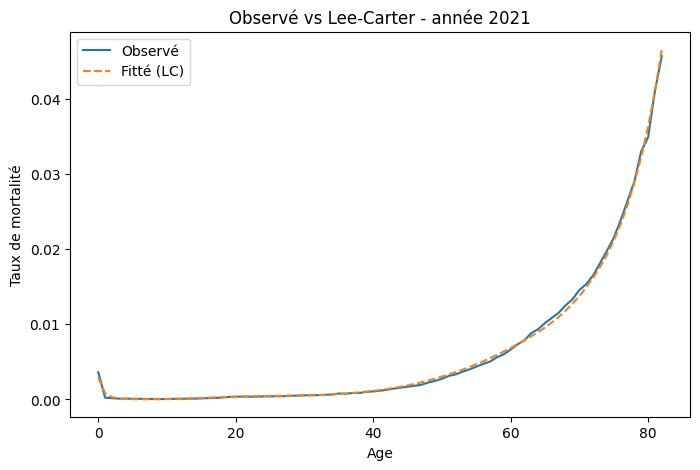

In [39]:
mu_obs = Dxt / np.maximum(Ext, 1e-12)
import matplotlib.pyplot as plt

t_index = -4  # dernière année

plt.figure(figsize=(8,5))

plt.plot(xv, mu_obs[:, t_index], label="Observé")
plt.plot(xv, mu_fit[:, t_index], label="Fitté (LC)", linestyle="--")

plt.xlabel("Age")
plt.ylabel("Taux de mortalité")
plt.title(f"Observé vs Lee-Carter - année {tv[t_index]}")
plt.legend()
plt.show()

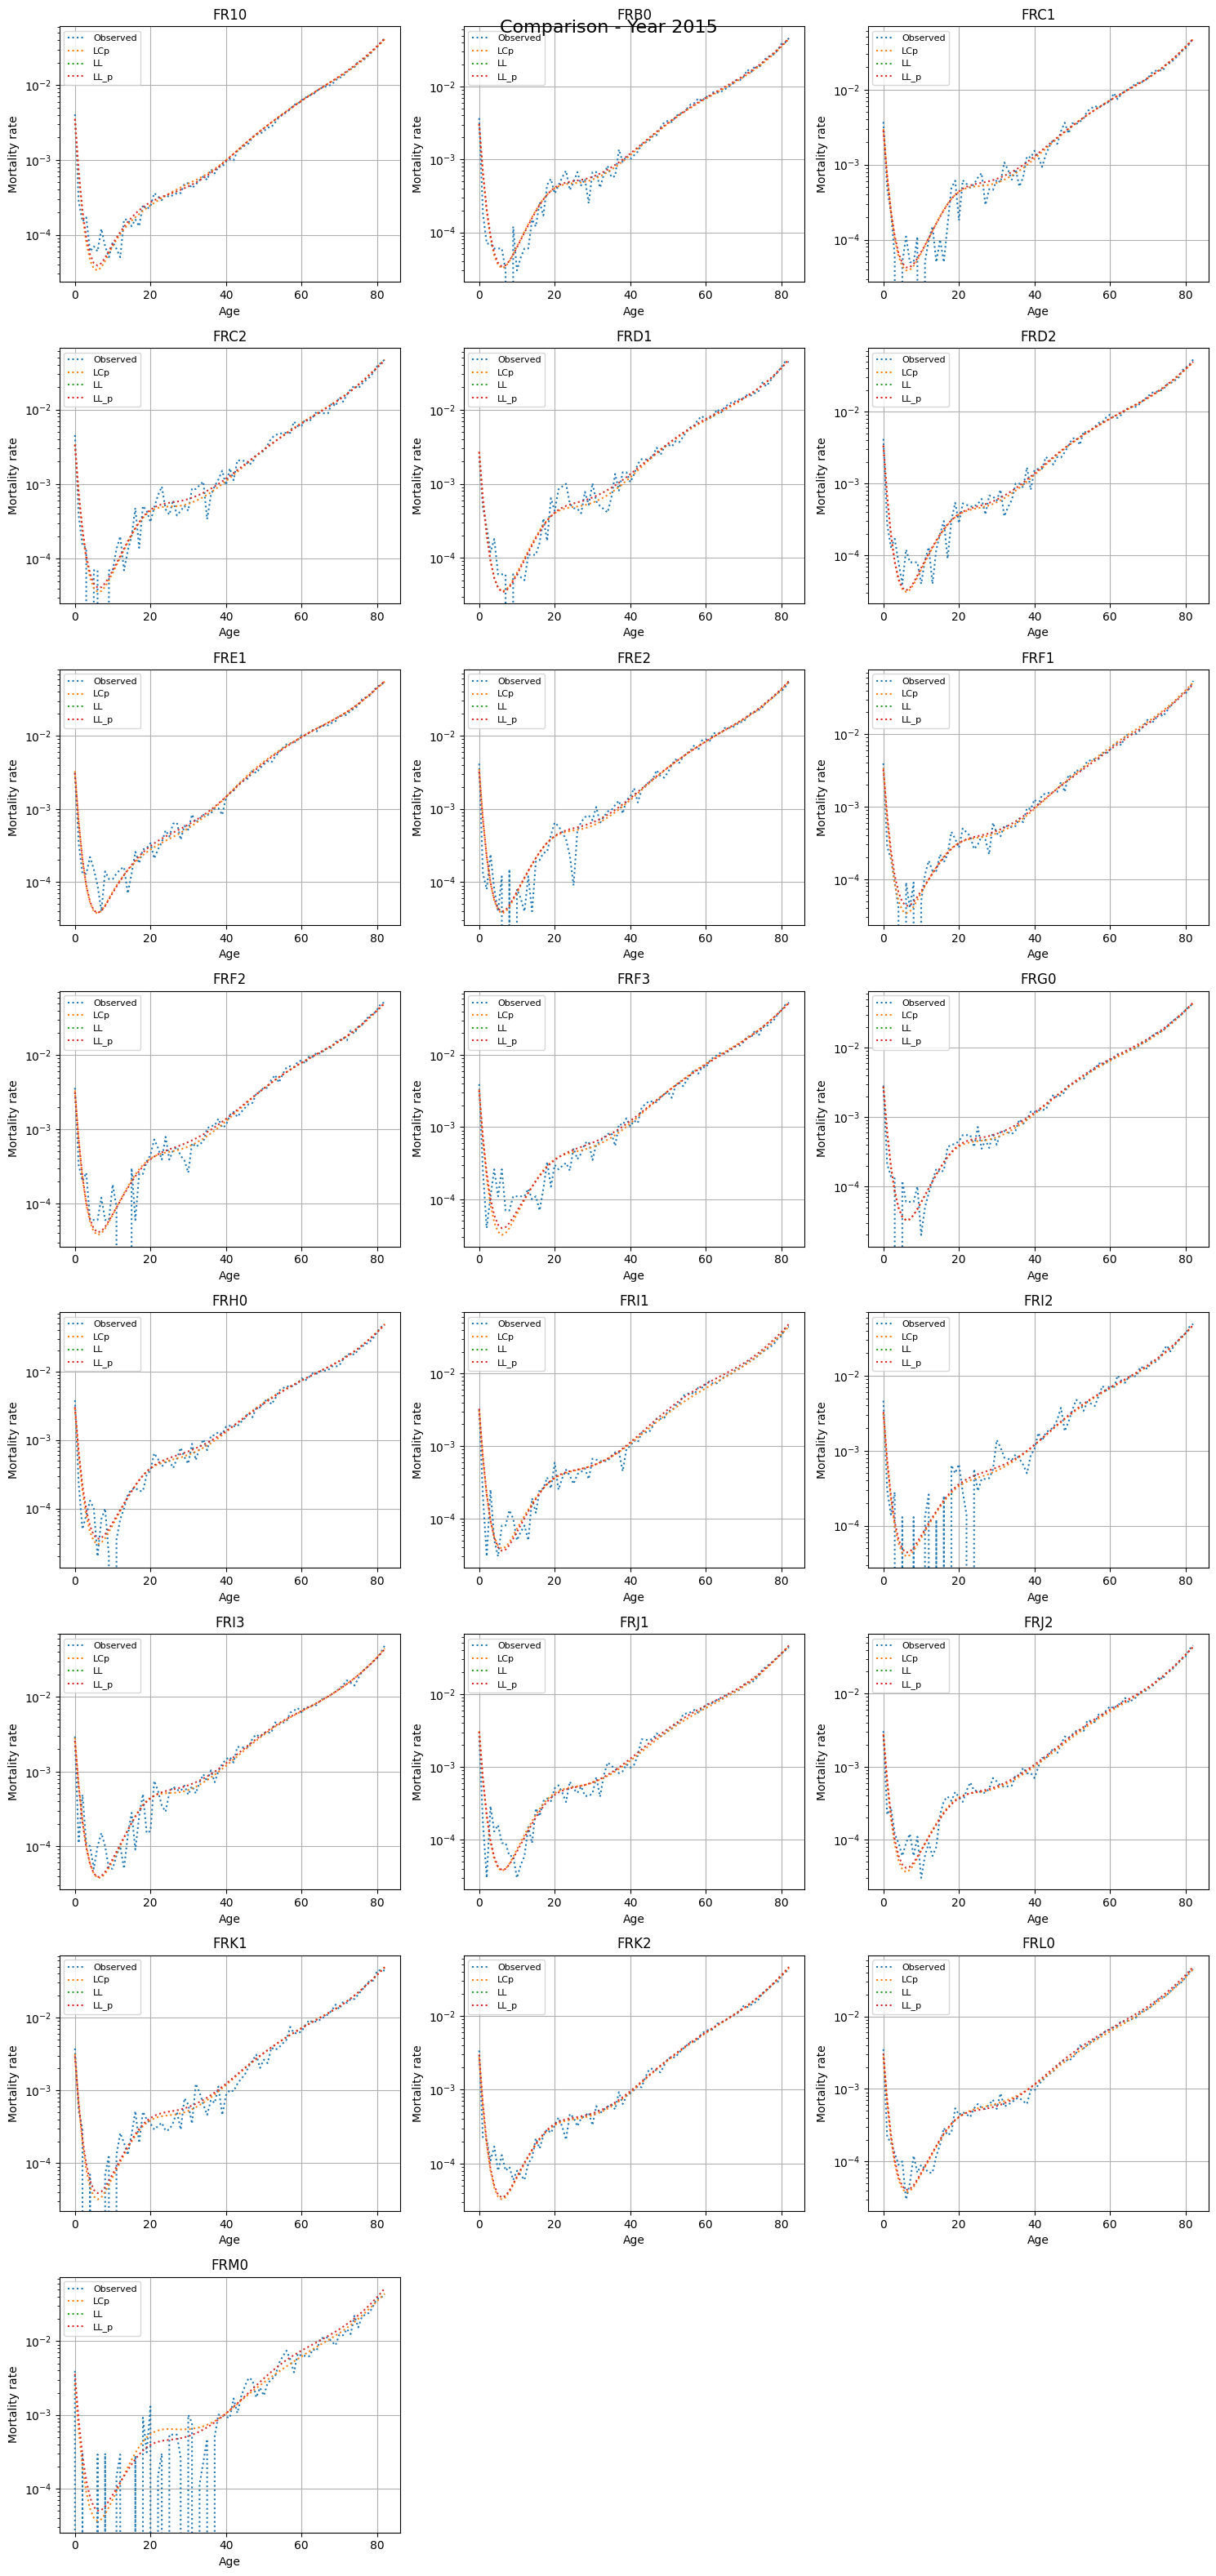

In [40]:
plot_models_by_region(
                    x_values=xv,
                    curves_dict=curves,
                    year_to_plot=2015,
                    tv=tv,
                    regions=regions)

### Projection des taux et extrapolation

##### Lee carter

In [41]:
proj_sto = project_LC_prospective_SVD(
    result_lcp,
    tv,
    horizon=27,
    nb_components=1,
    exclude_years=[2019,2020,2021],
    stochastic=False,
    n_sim=1000,
    model="rw"
    )


In [42]:
# proj_sto_1 = project_LC_prospective_SVD(
#     result_lcp,
#     tv,
#     horizon=27,
#     nb_components=1,
#     exclude_years=[2020,2021],
#     stochastic=True,
#     n_sim=5000,
#     model="rw"
    
# )

##### Lee and Li

In [43]:
proj_leeandli = project_LeeLi_prospective( resultat_llp,
    tv,
    horizon=27,
    exclude_years=[2019,2020,2021],
    stochastic=False,
    n_sim=1000,
    model="rw")

In [44]:
# proj_leeandli = project_LeeLi_prospective( resultat_llp,
#     tv,
#     horizon=27,
#     exclude_years=[2020,2021],
#     stochastic=True,
#     n_sim=5000,
#     model="rw")

##### Extrapolation

In [45]:
start_age = 70

In [46]:
# ── 2. Extrapolation 82 → 110 ─────────────────────────────────────
logmu_extrap_lcp, xv_full = high_age_extrapolation_snd(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = start_age,        # début de la fenêtre de régression commencer à 60 ans 
    log_Muxtg   = proj_sto["logmu_future"], auto_start =False)
    

# logmu_extrap
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_extrap_lcp.shape)   
print("Grille d'âges    :", xv_full[[0, -1]])  

log-mu extrapolé : (111, 27, 22)
Grille d'âges    : [  0 110]


In [47]:
# ── 2. Extrapolation 82 → 110 ─────────────────────────────────────
logmu_extrap_llp, xv_full = high_age_extrapolation_snd(
                    xv          = xv,
                    x_extrap    = 110,          # âge cible
                    x_extrap_start = start_age,        # début de la fenêtre de régression
                    log_Muxtg   = proj_leeandli["logmu_future"],auto_start =False
                )
# logmu_extrap
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_extrap_llp.shape)   
print("Grille d'âges    :", xv_full[[0, -1]])      

log-mu extrapolé : (111, 27, 22)
Grille d'âges    : [  0 110]


In [48]:
# ── 2. Extrapolation 82 → 110 ## Lee carter paramétrique
logmu_lcp_hist, xv_full = high_age_extrapolation_snd(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = start_age,        # début de la fenêtre de régression
    log_Muxtg   = result_lcp["fitted_values"]["log_mu"],auto_start =False
)
# logmu_extrap 
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_lcp_hist.shape)  
print("Grille d'âges    :", xv_full[[0, -1]])      # [  0 110]

log-mu extrapolé : (111, 35, 22)
Grille d'âges    : [  0 110]


In [49]:
logmu_llp_hist, xv_full = high_age_extrapolation_snd(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = start_age,        # début de la fenêtre de régression
    log_Muxtg   = resultat_llp["fitted_values"]["log_mu"],auto_start =False
)
# logmu_extrap → (111, 3, 30, 500)
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_llp_hist.shape)   # (111, 3, 30, 500)
print("Grille d'âges    :", xv_full[[0, -1]])  

log-mu extrapolé : (111, 35, 22)
Grille d'âges    : [  0 110]


In [50]:
#pour stochastique
import numpy as np

def concat_logmu_time(logmu_hist, logmu_proj):
    

    # Cas déterministe
    if logmu_proj.ndim == 3:
        return np.concatenate([logmu_hist, logmu_proj], axis=1)

    # Cas stochastique
    elif logmu_proj.ndim == 4:
        n_sim = logmu_proj.shape[2]

        logmu_hist_expanded = np.repeat(
            logmu_hist[:, :, None, :],
            n_sim,
            axis=2
        )

        return np.concatenate([logmu_hist_expanded, logmu_proj], axis=1)

    else:
        raise ValueError("Format non supporté")
    
# logmu_full_lcp_sto = concat_logmu_time(logmu_lcp_hist,np.transpose(logmu_extrap_lcp,(0, 3, 2,1)))
# logmu_full_llp_sto = concat_logmu_time(logmu_llp_hist,np.transpose(logmu_extrap_lcp,(0, 3, 2,1)))

logmu_full_lcp = concat_logmu_time(logmu_lcp_hist,logmu_extrap_lcp)
logmu_full_llp = concat_logmu_time(logmu_llp_hist,logmu_extrap_llp)

In [51]:
print(logmu_lcp_hist.shape)
print(logmu_extrap_lcp.shape)

(111, 35, 22)
(111, 27, 22)


In [52]:
# logmu_full_lcp = np.concatenate([logmu_lcp_hist, np.transpose(logmu_extrap_lcp,(0, 2, 1))], axis=1)
# print("log-mu lcp extrapolé :", logmu_full_lcp.shape) 

In [53]:
# logmu_full_llp = np.concatenate([logmu_llp_hist, np.transpose(logmu_extrap_llp,(0, 2, 1))], axis=1)
# print("log-mu llp extrapolé :", logmu_full_llp.shape)

In [54]:
esp_lcp = life_expectancy(np.exp(logmu_full_lcp))
esp_llp = life_expectancy(np.exp(logmu_full_llp))

In [55]:
esp_lcp

array([[[ 77.53433216,  76.6091094 ,  76.10973022, ...,  77.48848324,
          76.87653328,  76.80282563],
        [ 77.68033846,  76.75289673,  76.25261183, ...,  77.62855632,
          77.02121195,  76.94961803],
        [ 78.04355333,  77.11031029,  76.60774002, ...,  77.97654317,
          77.3806434 ,  77.3143528 ],
        ...,
        [111.        , 111.        , 111.        , ..., 111.        ,
         111.        , 111.        ],
        [111.        , 111.        , 111.        , ..., 111.        ,
         111.        , 111.        ],
        [111.        , 111.        , 111.        , ..., 111.        ,
         111.        , 111.        ]],

       [[ 77.0151059 ,  76.02569515,  75.51986552, ...,  76.87911409,
          76.26608916,  76.18271265],
        [ 77.15576301,  76.16458318,  75.65790607, ...,  77.01442488,
          76.40605681,  76.32487801],
        [ 77.50584982,  76.50998566,  76.00116673, ...,  77.35074576,
          76.75394497,  76.67827698],
        ...,


#### Visualisation graphique

In [56]:
#Paramètre
tv_future = np.arange(1990, 2023 + 28) #années

In [57]:
# # e₀ (age=0)
# t#v_future = np.arange(1990, 2023 + 28)
# plot_map_indicator(
#     regions        = regions,
#     data           = esp_vie_lcp,            # (111, horizon, 22)
#     tv_future      = tv_future,
#     country_code   = "FR",
#     indicator_name = "Espérance de vie",
#     year           = 2050,
#     age            = 0,             # ← e₀
# )


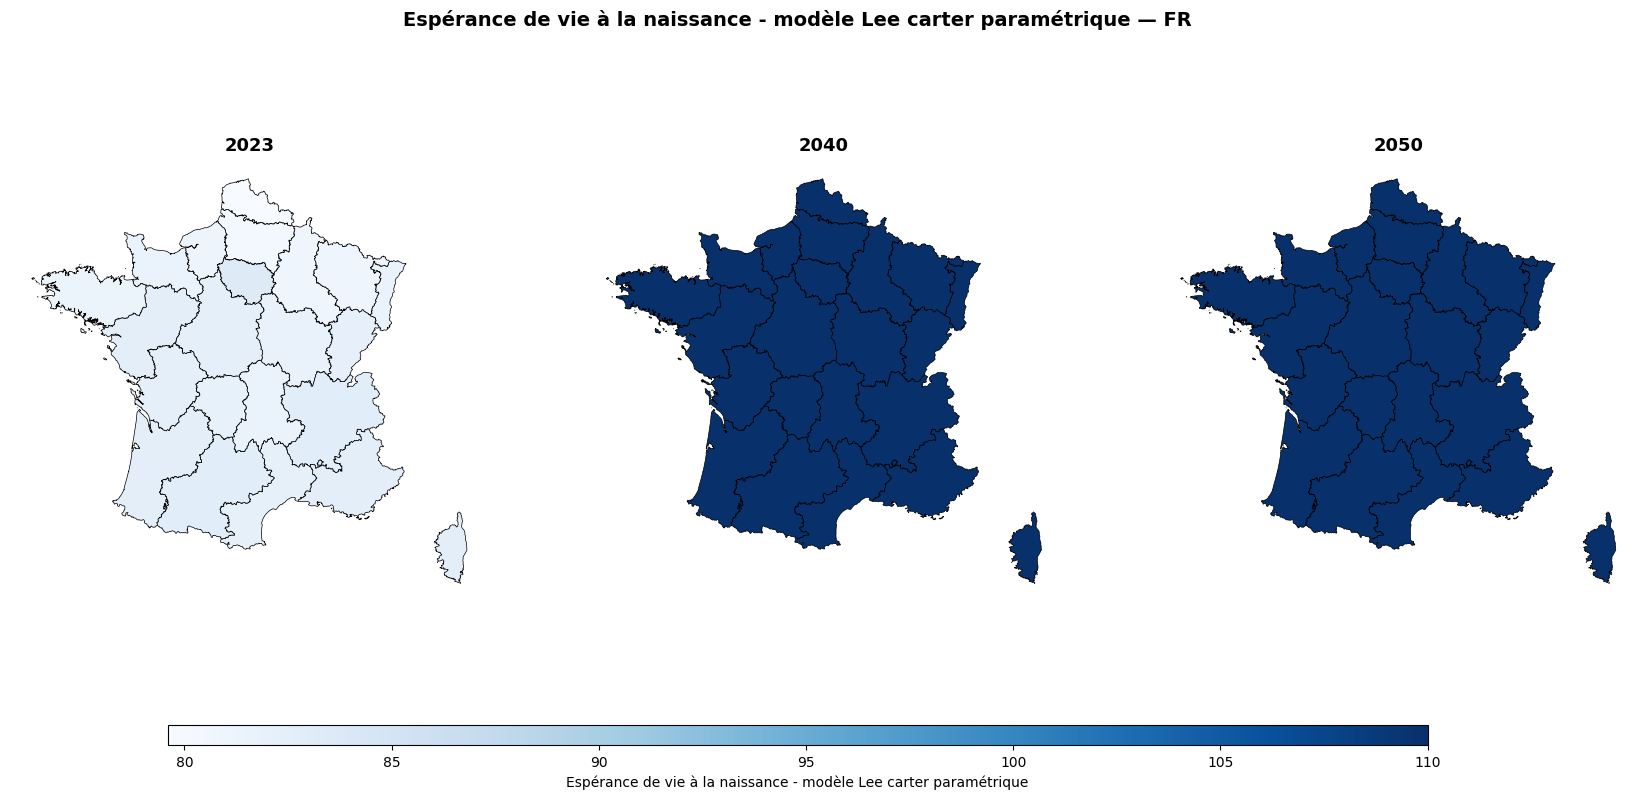

In [ ]:

plot_map_compare_years(
    regions=regions, data=esp_lcp,
    tv_future=tv_future, country_code="FR",
    indicator_name="Espérance de vie à la naissance - modèle Lee carter paramétrique",
    years=[2023,2040, 2050], age=0, cmap="Blues"
)

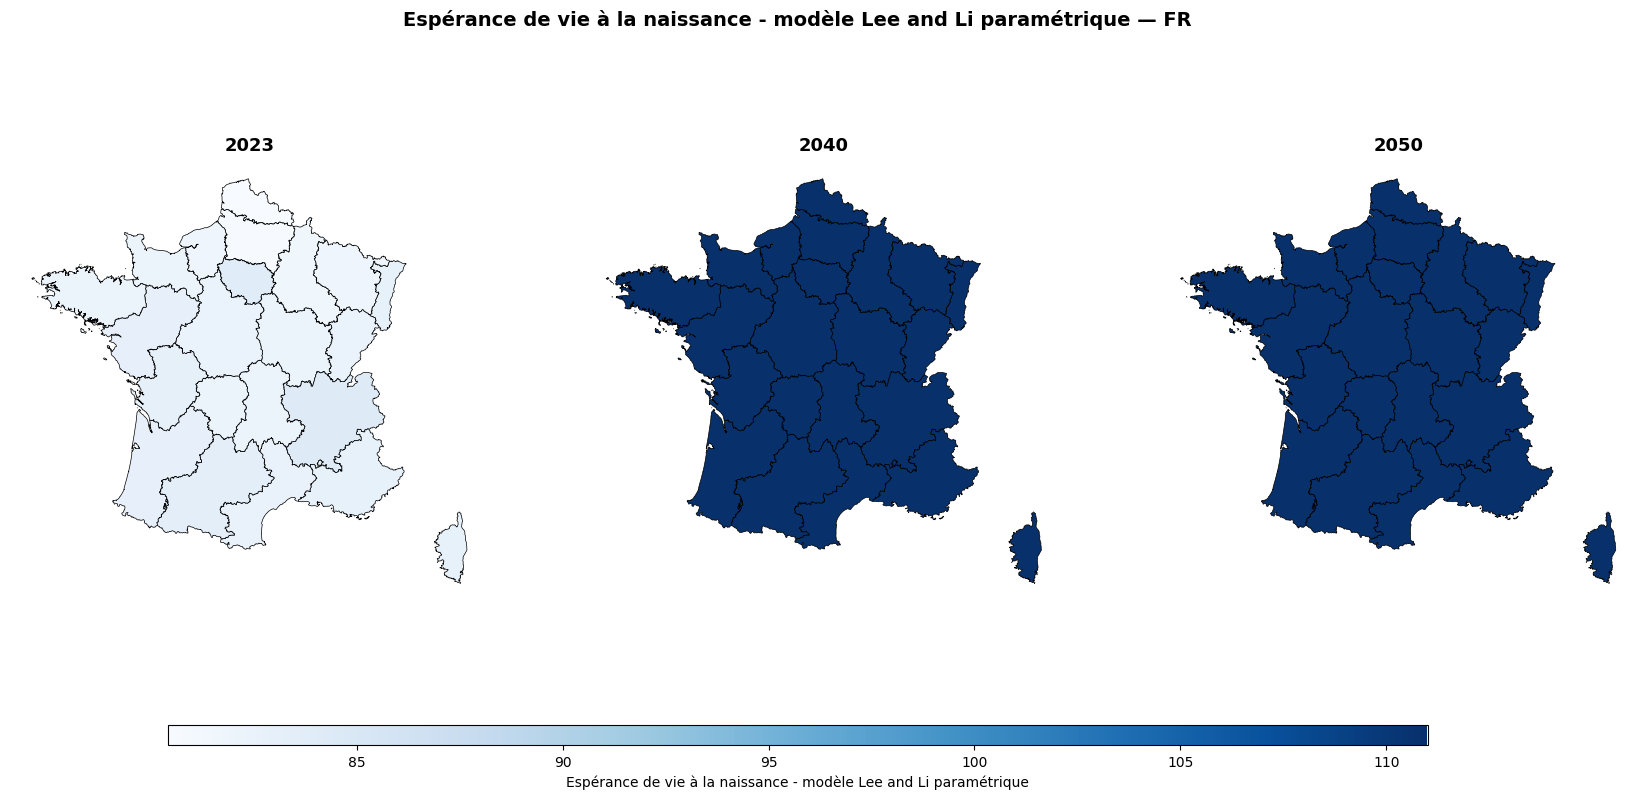

In [59]:
plot_map_compare_years(
    regions=regions, data=esp_llp,
    tv_future=tv_future, country_code="FR",
    indicator_name="Espérance de vie à la naissance - modèle Lee and Li paramétrique",
    years=[2023,2040, 2050], age=0, cmap="Blues"
)

ValueError: x and y must have same first dimension, but have shapes (61,) and (62,)

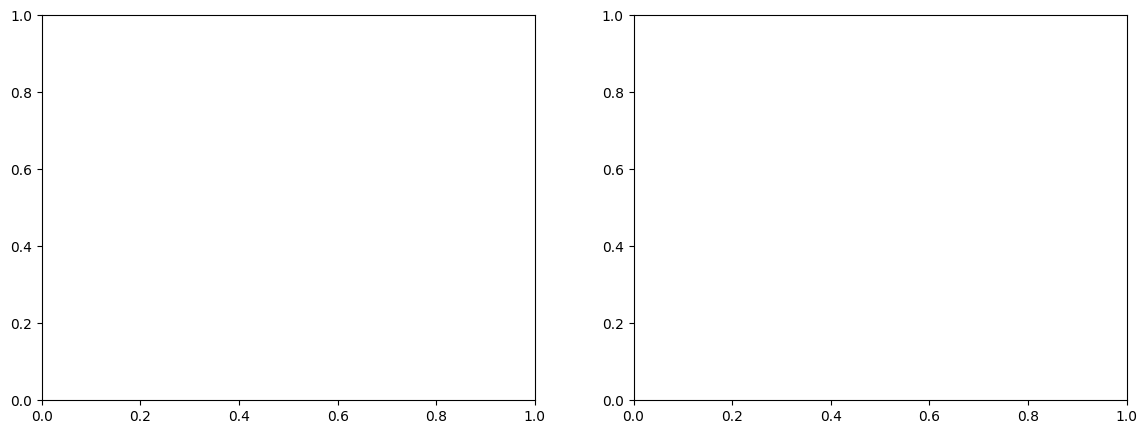

In [404]:
# 3. Convergence inter-régionale
plot_dispersion_over_time(
    ex        = esp_llp,
    regions   = regions,
    tv_future = tv_future,
    ages      = [0, 60],
)

In [70]:
# #  Stats régionales
# stats = compute_regional_stats(esp_vie, regions, tv_future, age=0)
# print(stats["by_year"].head())      # stats par année
# print(stats["by_region"])           # classement régions



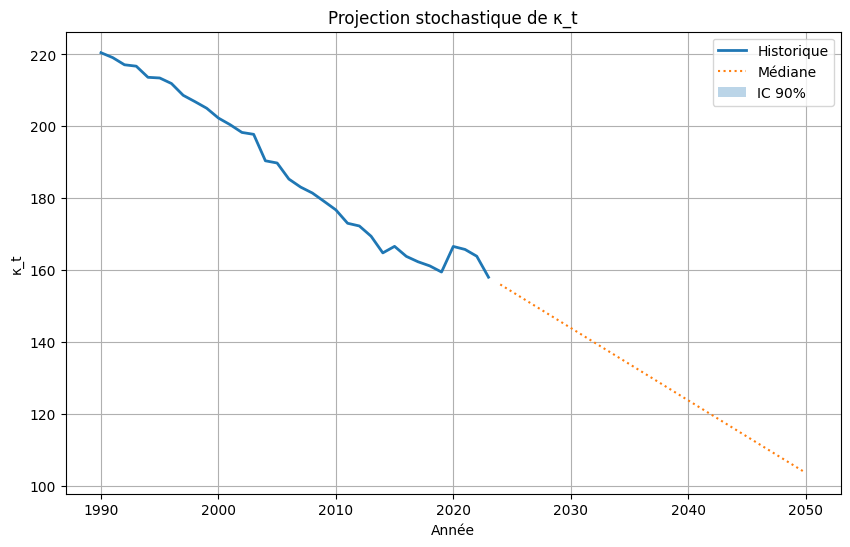

In [ ]:
# #visualisation Kappaa

# def plot_kappa_stochastic(tv, kappa_hist, kappa_paths):
    
#     horizon, n_sim = kappa_paths.shape
#     future_years = np.arange(tv[-1] + 1, tv[-1] + 1 + horizon)
    
#     kappa_lower = np.percentile(kappa_paths, 5, axis=1)
#     kappa_median = np.percentile(kappa_paths, 50, axis=1)
#     kappa_upper = np.percentile(kappa_paths, 95, axis=1)
#     kappa_proje = kappa_paths
#     plt.figure(figsize=(10,6))
    
#     plt.plot(tv, kappa_hist, label="Historique", linewidth=2)
    
#     plt.plot(future_years, kappa_paths, label="Médiane", linestyle=":")
#     plt.fill_between(
#         future_years,
#         kappa_lower,
#         kappa_upper,
#         alpha=0.3,
#         label="IC 90%"
#     )
    
#     #plt.axvline(tv[-1], color="black", linestyle=":")
    
#     plt.title("Projection stochastique de κ_t")
#     plt.xlabel("Année")
#     plt.ylabel("κ_t")
#     plt.legend()
#     plt.grid(True)
#     plt.show()
# plot_kappa_stochastic(tv,result_lcp['parameters']["kappa"],proj_sto["kappa_future"])

### Annexes

In [51]:
shapef = gpd.read_file("C:/Users/Idrissa Belem/Documents/GitHub/test_projet/NUTS_files/NUTS_RG_01M_2024_3035.shp")
stock = "C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data"
mxt_raw = load_mxt_raw(shapef,country="FR",data_path=stock)
Dxt_raw = load_dxt_raw(shapef,country="FR",data_path=stock)
Lxt_raw = load_lxt_raw(shapef,country="FR",data_path=stock)

[Eurostat] Téléchargé → C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data\FR_mxt_raw_FR.csv  (1,543,872 lignes)
[Eurostat] Chargé depuis cache → C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data\FR_Dxt_raw_FR.csv  (231,132 lignes)
[Eurostat] Téléchargé → C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data\FR_Lxt_raw_FR.csv  (244,728 lignes)
